# Data Loading and Augmentation Using Keras

**Course:** AI Capstone Project with Deep Learning (IBM) — Module 1

**Objective:** Build a custom Keras data generator to understand on-the-fly
data loading and augmentation, then compare it against Keras' built-in
`tf.keras.utils.image_dataset_from_directory` + `tf.data` pipeline, which
is the production-ready approach.

**Dataset:** `images_dataSAT/class_0_non_agri` and `images_dataSAT/class_1_agri`
(3,000 images each, 64x64 RGB).


## 1. Import libraries and packages

In [1]:
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

tf.random.set_seed(42)
np.random.seed(42)


I0000 00:00:1782892401.494542     948 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782892401.537019     948 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1782892402.877436     948 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Keras: 3.15.0


## 2. Locate the dataset

In [2]:
DATA_DIR = Path("images_dataSAT")
assert DATA_DIR.exists(), f"'{DATA_DIR}' not found in the working directory."

class_dirs = {
    0: DATA_DIR / "class_0_non_agri",
    1: DATA_DIR / "class_1_agri",
}

all_paths, all_labels = [], []
for label, d in class_dirs.items():
    paths = sorted(d.glob("*.jpg"))
    all_paths.extend(paths)
    all_labels.extend([label] * len(paths))

all_paths = np.array([str(p) for p in all_paths])
all_labels = np.array(all_labels)

print(f"Total images: {len(all_paths)}  (class 0 / non-agri: {(all_labels==0).sum()}, "
      f"class 1 / agri: {(all_labels==1).sum()})")


Total images: 6000  (class 0 / non-agri: 3000, class 1 / agri: 3000)


## 3. Custom Keras data generator

We build a custom `keras.utils.Sequence` subclass. This is the classic way
of writing a Keras data generator: it controls exactly how images are
read, augmented, and batched, and integrates directly with `model.fit()`.


In [3]:
class SatelliteImageGenerator(keras.utils.Sequence):
    """Custom Keras Sequence: loads images from disk on demand, with
    optional simple on-the-fly augmentation (random flips).
    """

    def __init__(self, paths, labels, batch_size=32, image_size=(64, 64),
                 augment=False, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.paths = np.array(paths)
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.image_size = image_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size: (idx + 1) * self.batch_size]
        batch_paths = self.paths[batch_idx]
        batch_labels = self.labels[batch_idx]

        images = np.zeros((len(batch_paths), *self.image_size, 3), dtype=np.float32)
        for i, p in enumerate(batch_paths):
            img = keras.utils.load_img(p, target_size=self.image_size)
            arr = keras.utils.img_to_array(img) / 255.0
            if self.augment:
                if np.random.rand() < 0.5:
                    arr = np.fliplr(arr)
                if np.random.rand() < 0.5:
                    arr = np.flipud(arr)
            images[i] = arr

        return images, batch_labels.astype(np.float32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = SatelliteImageGenerator(all_paths, all_labels, batch_size=32, augment=True)
print(f"Custom generator: {len(train_gen)} batches per epoch")

t0 = time.perf_counter()
xb, yb = train_gen[0]
t1 = time.perf_counter()
print(f"First batch shape: {xb.shape}, labels shape: {yb.shape}")
print(f"Time for first batch: {t1 - t0:.4f} s")


Custom generator: 188 batches per epoch
First batch shape: (32, 64, 64, 3), labels shape: (32,)
Time for first batch: 0.0104 s


## 4. Keras built-in utility: `image_dataset_from_directory`

The custom generator above is useful for understanding the mechanics, but
for real projects Keras' built-in `image_dataset_from_directory`, combined
with the `tf.data` API, is the preferred, more performant option: it
handles parallel file reading, prefetching, and caching automatically.


In [4]:
batch_size = 32
img_size = (64, 64)

train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["class_0_non_agri", "class_1_agri"],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training",
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["class_0_non_agri", "class_1_agri"],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation",
)

print("Class names (0=non-agri, 1=agri):", train_ds.class_names)


Found 6000 files belonging to 2 classes.


Using 4800 files for training.


Found 6000 files belonging to 2 classes.


Using 1200 files for validation.


Class names (0=non-agri, 1=agri): ['class_0_non_agri', 'class_1_agri']


## 5. Image augmentation

We apply augmentation as Keras preprocessing layers, which can be attached
directly to the `tf.data` pipeline (or baked into the model itself).


In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

# Normalize pixel values to [0, 1] and apply augmentation only on the training set
normalization = layers.Rescaling(1.0 / 255)

def prepare(ds, augment=False, shuffle=False):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds_ready = prepare(train_ds, augment=True, shuffle=True)
val_ds_ready = prepare(val_ds, augment=False, shuffle=False)

print("Pipelines built with caching + prefetching (tf.data.AUTOTUNE).")


Pipelines built with caching + prefetching (tf.data.AUTOTUNE).


## 6. Visualize augmented samples

W0000 00:00:1782892408.492551     948 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


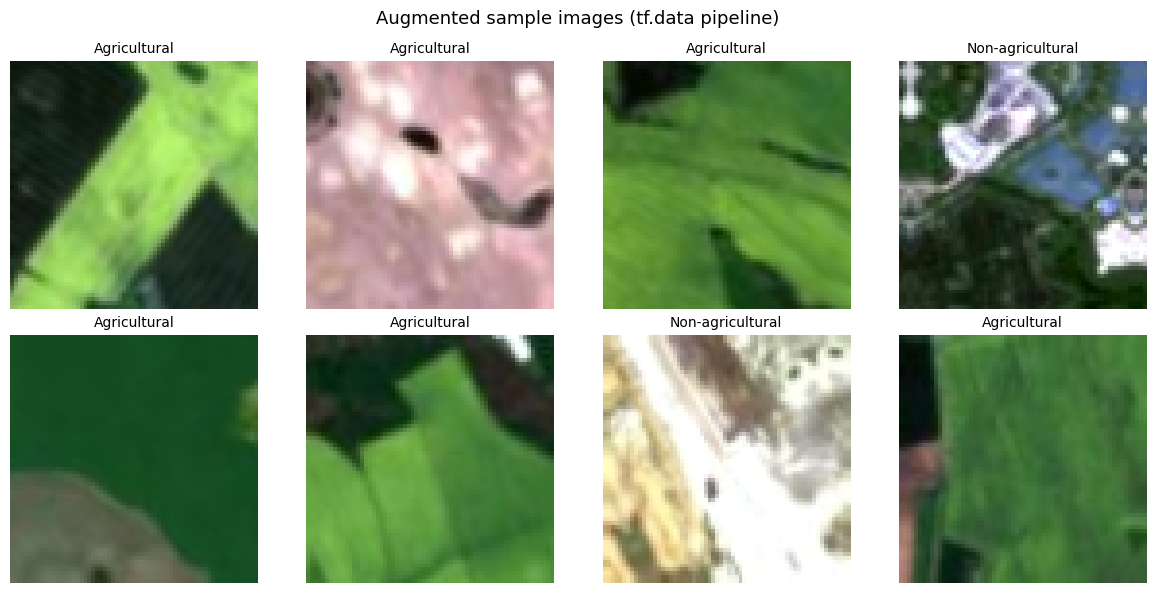

In [6]:
sample_batch_x, sample_batch_y = next(iter(train_ds_ready))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flat, sample_batch_x[:8], sample_batch_y[:8]):
    ax.imshow(np.clip(img.numpy(), 0, 1))
    label_str = "Agricultural" if label.numpy()[0] == 1 else "Non-agricultural"
    ax.set_title(label_str, fontsize=10)
    ax.axis("off")

plt.suptitle("Augmented sample images (tf.data pipeline)", fontsize=13)
plt.tight_layout()
plt.show()


## 7. Custom generator vs. built-in pipeline — comparison

| Aspect | Custom `Sequence` | `image_dataset_from_directory` + `tf.data` |
|---|---|---|
| Lines of code | More — you write file I/O, batching, augmentation, shuffling yourself | Fewer — most of it is handled for you |
| Performance | Single-threaded by default (unless you add `use_multiprocessing`) | Multi-threaded, parallel I/O, prefetching via `tf.data.AUTOTUNE` out of the box |
| Flexibility | Full control over exactly what happens per sample | Very flexible too, especially combined with `tf.data.Dataset.map()` |
| Best for | Learning the mechanics; unusual/custom loading logic | Real projects — the recommended, production-ready default |


In [7]:
for name, ds in [("Custom generator (1 batch)", None), ("tf.data pipeline (1 batch)", train_ds_ready)]:
    if ds is None:
        t0 = time.perf_counter()
        _ = train_gen[0]
        t1 = time.perf_counter()
    else:
        t0 = time.perf_counter()
        _ = next(iter(ds))
        t1 = time.perf_counter()
    print(f"{name:<30}: {t1 - t0:.4f} s")


Custom generator (1 batch)    : 0.0063 s


W0000 00:00:1782892414.163056     948 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


tf.data pipeline (1 batch)    : 5.1056 s


## Summary

In this lab, a custom `keras.utils.Sequence` data generator was built as an
exercise to understand the principles of on-the-fly data loading and
augmentation. We then used Keras' built-in `image_dataset_from_directory`,
which is the preferred choice for real-world projects over custom-written
generators — leveraging the `tf.data` API ensures the data pipeline can
keep up with modern hardware during training, preventing data loading from
becoming a training bottleneck.
